
# Détection de fraude — 4 patterns heuristiques

Chaque pattern est détecté par une règle explicite, calibrée sur le comportement **propre à chaque carte** (pas de seuils globaux).

| # | Pattern | Signal clé |
|---|---------|------------|
| 1 | **Card Testing** | Micro-charges en rafale en ligne |
| 2 | **Cashout** | Achat élevé gift card / électronique vs profil carte |
| 3 | **Merchant Ring** | Marchand qui surcharge plusieurs cartes (cross-carte) |
| 4 | **Impossible Travel** | Transaction physique hors pays d'attache |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize

plt.rcParams.update({"figure.dpi": 130, "axes.spines.top": False, "axes.spines.right": False})

df = pd.read_csv("transactions.csv", parse_dates=["timestamp"])

# Baseline par carte : médiane et MAD (robuste à la fraude dans l'historique)
def baselines(df):
    def _s(g):
        med = g["amount"].median()
        return pd.Series({"median": med, "mad": (g["amount"] - med).abs().median()})
    return df.groupby("card_id").apply(_s)

bl = baselines(df)
print(f"{len(df)} transactions · {df['card_id'].nunique()} cartes · {df['merchant_name'].nunique()} marchands")

1000 transactions · 50 cartes · 41 marchands


---
## Pattern 1 — Card Testing (Burst)

**Comportement** : un fraudeur teste une carte volée avec des micro-charges en ligne, en quelques minutes, sur plusieurs marchands différents.

**Heuristique**
```
≥ 5 transactions  ·  canal = online  ·  même carte  ·  fenêtre ≤ 30 min  ·  médiane montant < 20 $
```

Cartes flaggées (4) : ['card_023', 'card_038', 'card_042', 'card_049']


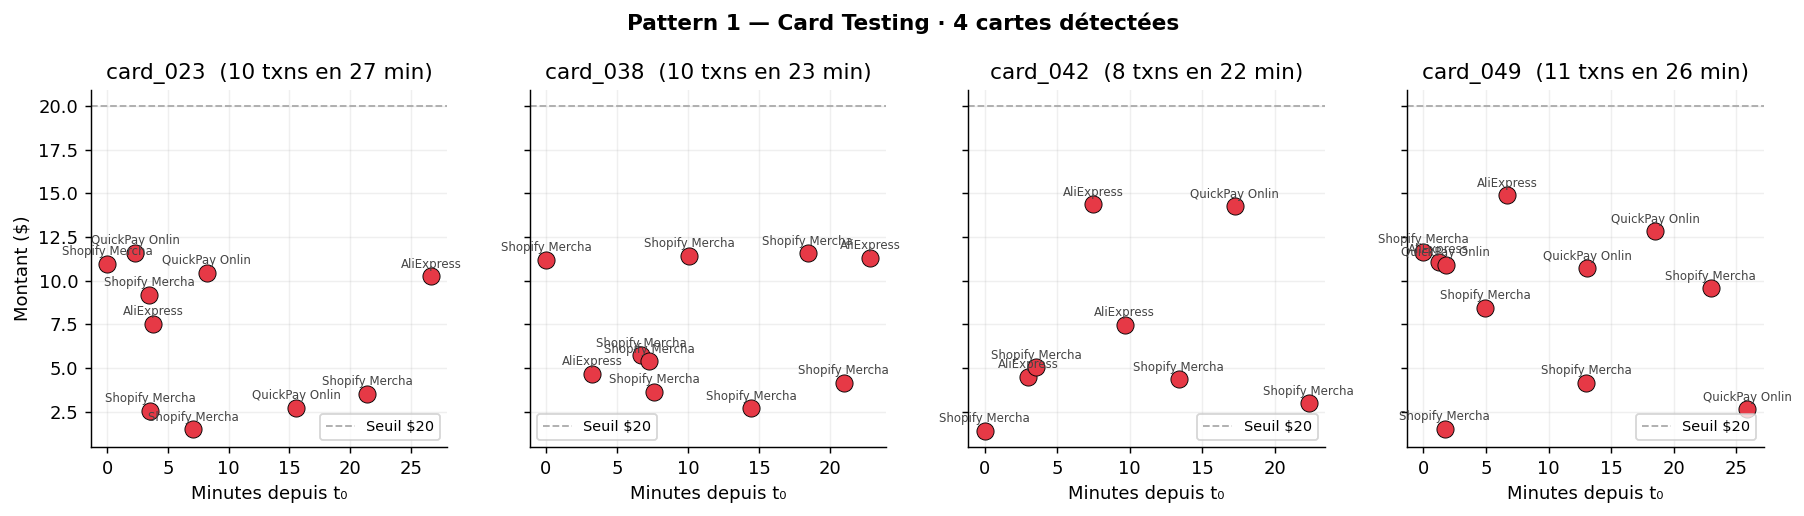

In [2]:
BURST_WIN = pd.Timedelta(minutes=30)
BURST_N   = 5
BURST_AMT = 20.0

bursts = {}
for card, g in df.groupby("card_id"):
    g = g[g["channel"] == "online"].sort_values("timestamp")
    for i in range(len(g)):
        win = g[(g["timestamp"] >= g["timestamp"].iloc[i]) &
                (g["timestamp"] <  g["timestamp"].iloc[i] + BURST_WIN)]
        if len(win) >= BURST_N and win["amount"].median() < BURST_AMT:
            bursts[card] = win
            break

print(f"Cartes flaggées ({len(bursts)}) : {list(bursts)}")

fig, axes = plt.subplots(1, len(bursts), figsize=(14, 4), sharey=True)
if len(bursts) == 1: axes = [axes]

for ax, (card, win) in zip(axes, bursts.items()):
    t0 = win["timestamp"].iloc[0]
    mins = (win["timestamp"] - t0).dt.total_seconds() / 60
    ax.scatter(mins, win["amount"], s=90, color="#E63946", edgecolors="black", lw=0.5, zorder=3)
    ax.axhline(BURST_AMT, color="#aaa", ls="--", lw=1, label=f"Seuil ${BURST_AMT:.0f}")
    for m, (_, r) in zip(mins, win.iterrows()):
        ax.text(m, r["amount"] + 0.5, r["merchant_name"][:14], fontsize=6.5, ha="center", color="#444")
    ax.set(title=f"{card}  ({len(win)} txns en {mins.iloc[-1]:.0f} min)",
           xlabel="Minutes depuis t₀", ylabel="Montant ($)" if ax is axes[0] else "")
    ax.legend(fontsize=8); ax.grid(alpha=0.2)

fig.suptitle(f"Pattern 1 — Card Testing · {len(bursts)} cartes détectées", fontweight="bold", fontsize=12)
plt.tight_layout()
plt.show()

---
## Pattern 2 — Cashout

**Comportement** : une carte compromise est utilisée pour acheter des gift cards ou de l'électronique à prix élevé — actifs facilement revendables en espèces.

**Heuristique**
```
catégorie ∈ {gift_card, electronics}  ·  montant ≥ 250 $  ·  z-score robuste ≥ 3× la médiane de la carte
```
> Le z-score robuste (basé sur la MAD) empêche de flaguer une carte qui *achète toujours* de l'électronique.

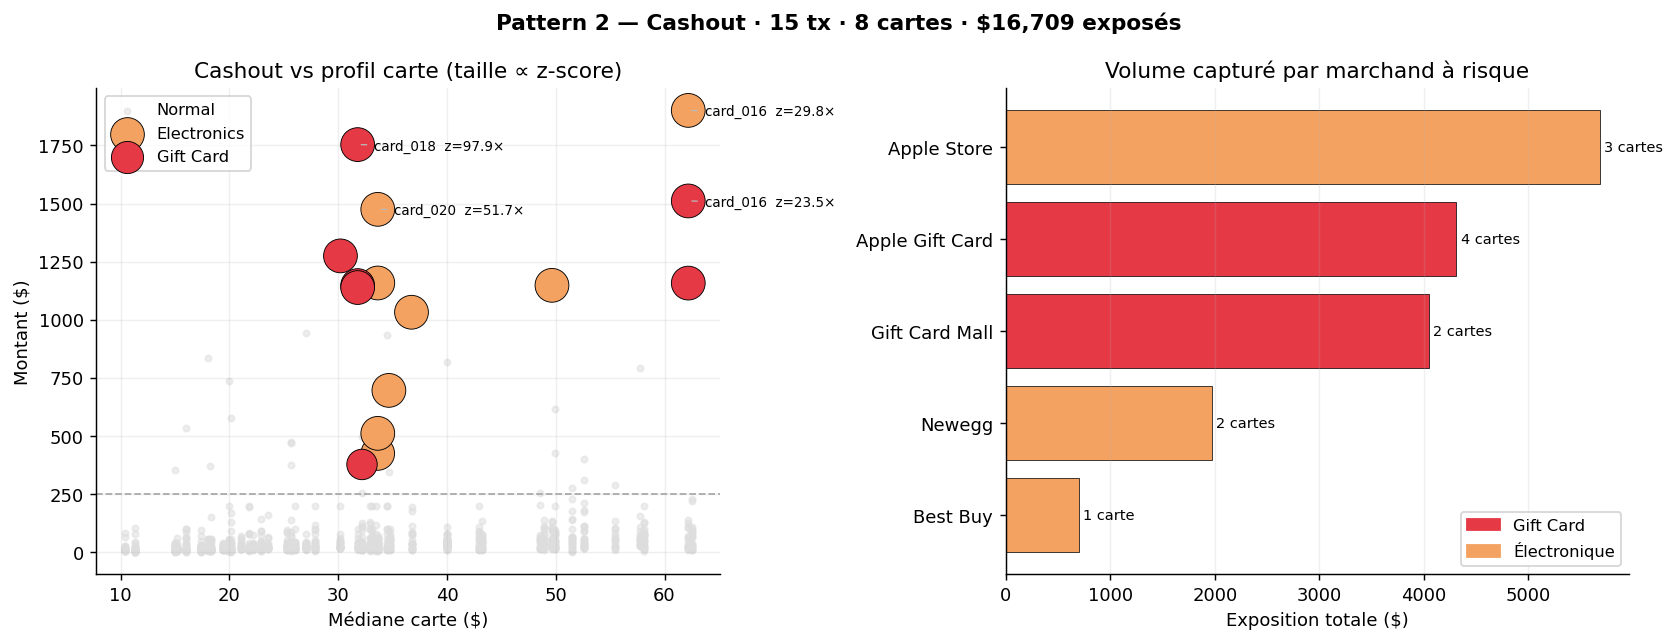

In [3]:
CASHOUT_CATS = {"gift_card", "electronics"}
CO_AMT = 250.0
CO_RZ  = 3.0

hits = df[df["merchant_category"].isin(CASHOUT_CATS) & (df["amount"] >= CO_AMT)].copy()
hits["card_med"] = hits["card_id"].map(bl["median"])
hits["rz"] = (hits["amount"] - hits["card_med"]) / (hits["card_id"].map(bl["mad"]) * 1.4826).clip(lower=1)
cashouts = hits[hits["rz"] >= CO_RZ]

palette = {"gift_card": "#E63946", "electronics": "#F4A261"}
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# --- scatter : profil carte vs montant cashout ---
ax1.scatter(bl.loc[df["card_id"], "median"], df["amount"],
            color="#ddd", s=12, alpha=0.5, zorder=1, label="Normal")
for cat, grp in cashouts.groupby("merchant_category"):
    ax1.scatter(grp["card_med"], grp["amount"],
                c=palette[cat], s=np.clip((grp["rz"] - CO_RZ) * 25 + 70, 70, 350),
                edgecolors="black", lw=0.5, zorder=3, label=cat.replace("_", " ").title())
ax1.axhline(CO_AMT, color="#aaa", ls="--", lw=1)
for _, r in cashouts.nlargest(4, "amount").iterrows():
    ax1.annotate(f"{r['card_id']}  z={r['rz']:.1f}×",
                 xy=(r["card_med"], r["amount"]), xytext=(9, -3), textcoords="offset points",
                 fontsize=7.5, arrowprops=dict(arrowstyle="-", color="#bbb", lw=0.7))
ax1.set(xlabel="Médiane carte ($)", ylabel="Montant ($)",
        title="Cashout vs profil carte (taille ∝ z-score)")
ax1.legend(fontsize=9); ax1.grid(alpha=0.2)

# --- barres : exposition par marchand ---
merch = (cashouts.groupby("merchant_name")
         .agg(total=("amount", "sum"), n_cards=("card_id", "nunique"))
         .sort_values("total"))
bar_c = [palette.get(cashouts[cashouts["merchant_name"] == m]["merchant_category"].iloc[0], "#888")
         for m in merch.index]
bars = ax2.barh(merch.index, merch["total"], color=bar_c, edgecolor="black", lw=0.4)
for bar, (_, row) in zip(bars, merch.iterrows()):
    ax2.text(bar.get_width() + 40, bar.get_y() + bar.get_height() / 2,
             f"{int(row['n_cards'])} carte{'s' if row['n_cards']>1 else ''}", va="center", fontsize=8)
ax2.set(xlabel="Exposition totale ($)", title="Volume capturé par marchand à risque")
ax2.grid(axis="x", alpha=0.2)
patches = [mpatches.Patch(color=c, label=l) for c, l in [("#E63946", "Gift Card"), ("#F4A261", "Électronique")]]
ax2.legend(handles=patches, fontsize=9)

fig.suptitle(f"Pattern 2 — Cashout · {len(cashouts)} tx · {cashouts['card_id'].nunique()} cartes · "
             f"${cashouts['amount'].sum():,.0f} exposés", fontweight="bold", fontsize=12)
plt.tight_layout()
plt.show()

---
## Pattern 3 — Merchant Ring

**Comportement** : un marchand compromis (ou complice) surcharge plusieurs cartes différentes. Invisible carte par carte — visible uniquement en agrégant au niveau marchand.

**Heuristique (cross-carte)**
```
montant > 5× médiane du marchand  ·  ET > 200 $  ·  ≥ 3 outliers  ·  depuis ≥ 3 cartes distinctes
```

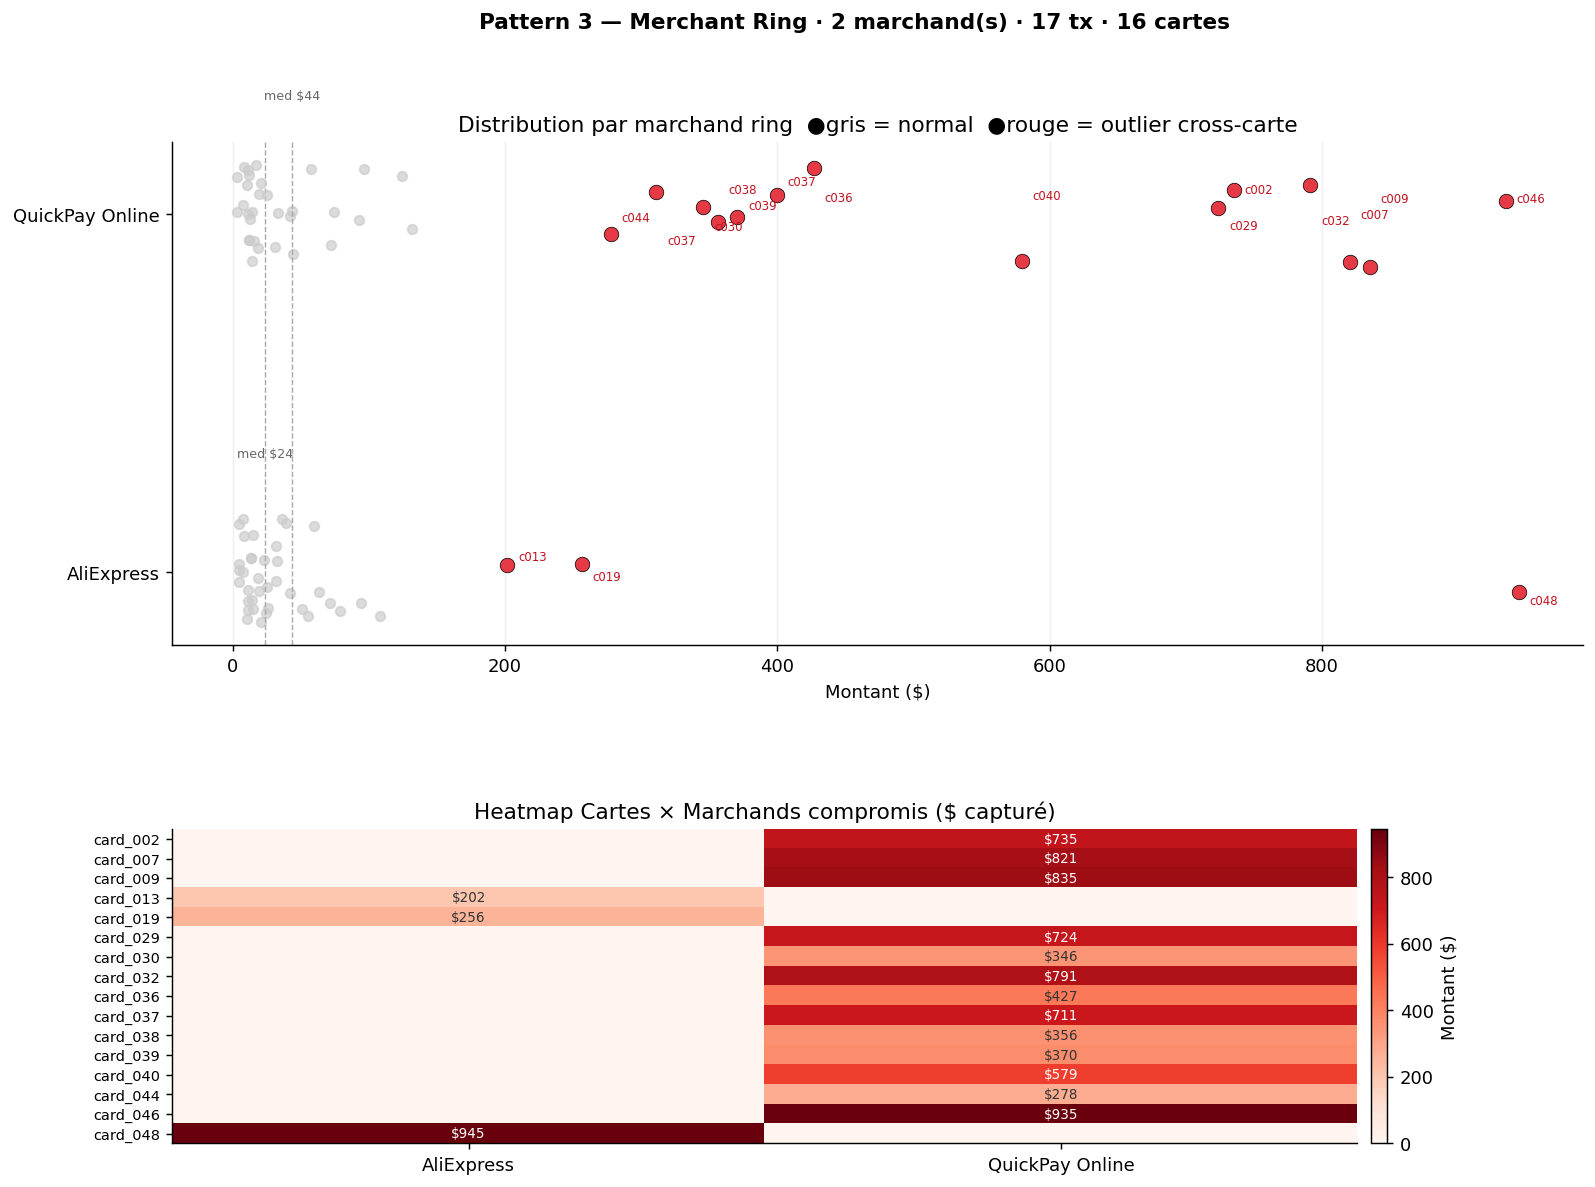

       marchand  n_tx  n_cartes  médiane_normale  moy_outlier     ratio  exposition
     AliExpress     3         3           23.595   467.650000 19.819877     1402.95
QuickPay Online    14        13           43.590   564.932143 12.960132     7909.05


In [4]:
RING_MULT  = 5.0
RING_AMT   = 200.0
RING_HITS  = 3
RING_CARDS = 3

ring_txns, ring_info = [], []
for merch, g in df.groupby("merchant_name"):
    med = g["amount"].median()
    hi  = g[(g["amount"] > RING_MULT * med) & (g["amount"] > RING_AMT)]
    if len(hi) >= RING_HITS and hi["card_id"].nunique() >= RING_CARDS:
        ring_txns.append(hi.assign(merchant_median=med))
        ring_info.append({"marchand": merch, "n_tx": len(hi),
                          "n_cartes": hi["card_id"].nunique(),
                          "médiane_normale": med, "moy_outlier": hi["amount"].mean(),
                          "ratio": hi["amount"].mean() / med,
                          "exposition": hi["amount"].sum()})

ring_df   = pd.concat(ring_txns, ignore_index=True)
ring_meta = pd.DataFrame(ring_info)
ring_names = ring_meta["marchand"].tolist()

fig = plt.figure(figsize=(14, 10))
gs  = fig.add_gridspec(2, 1, height_ratios=[1.6, 1], hspace=0.45)
ax_s = fig.add_subplot(gs[0])
ax_h = fig.add_subplot(gs[1])

# --- strip plot ---
outlier_ids = set(ring_df["transaction_id"])
for i, m in enumerate(ring_names):
    med  = ring_meta.loc[ring_meta["marchand"] == m, "médiane_normale"].iloc[0]
    grp  = df[df["merchant_name"] == m]
    norm = grp[~grp["transaction_id"].isin(outlier_ids)]
    out  = grp[ grp["transaction_id"].isin(outlier_ids)]
    j_n  = np.random.uniform(-0.15, 0.15, len(norm))
    j_o  = np.random.uniform(-0.15, 0.15, len(out))
    ax_s.scatter(norm["amount"], i + j_n, color="#CCC", s=28, alpha=0.7, zorder=2)
    ax_s.scatter(out["amount"],  i + j_o, color="#E63946", s=65, edgecolors="black", lw=0.4, zorder=3)
    ax_s.axvline(med, color="#aaa", lw=0.8, ls="--")
    ax_s.text(med, i + 0.32, f"med ${med:.0f}", fontsize=7, color="#666", ha="center")
    for _, r in out.iterrows():
        ax_s.text(r["amount"] + 8, i + np.random.uniform(-0.12, 0.12),
                  r["card_id"].replace("card_", "c"), fontsize=6.5, color="#C1121F", va="center")

ax_s.set_yticks(range(len(ring_names))); ax_s.set_yticklabels(ring_names, fontsize=10)
ax_s.set(xlabel="Montant ($)",
         title="Distribution par marchand ring  ●gris = normal  ●rouge = outlier cross-carte")
ax_s.grid(axis="x", alpha=0.2)

# --- heatmap cartes × marchands ---
cards  = sorted(ring_df["card_id"].unique())
mat    = pd.DataFrame(0.0, index=cards, columns=ring_names)
for _, r in ring_df.iterrows():
    mat.loc[r["card_id"], r["merchant_name"]] += r["amount"]
im = ax_h.imshow(mat.values, aspect="auto", cmap="Reds", norm=Normalize(0, mat.values.max()))
ax_h.set_xticks(range(len(ring_names))); ax_h.set_xticklabels(ring_names, fontsize=10)
ax_h.set_yticks(range(len(cards)));      ax_h.set_yticklabels(cards, fontsize=8)
ax_h.set_title("Heatmap Cartes × Marchands compromis ($ capturé)")
for i, c in enumerate(cards):
    for j, m in enumerate(ring_names):
        v = mat.loc[c, m]
        if v > 0:
            ax_h.text(j, i, f"${v:.0f}", ha="center", va="center", fontsize=7.5,
                      color="white" if v > mat.values.max() * 0.5 else "#333")
plt.colorbar(im, ax=ax_h, label="Montant ($)", pad=0.01)

fig.suptitle(f"Pattern 3 — Merchant Ring · {len(ring_names)} marchand(s) · "
             f"{len(ring_df)} tx · {ring_df['card_id'].nunique()} cartes",
             fontweight="bold", fontsize=12)
plt.show()

print(ring_meta.to_string(index=False))

---
## Pattern 4 — Impossible Travel

**Comportement** : une carte est utilisée physiquement dans un pays autre que son pays d'attache — signe de clonage ou de vol avec déplacement.

**Heuristique**
```
canal ∈ {in_person, atm}  ·  pays_marchand ≠ pays_dominant de la carte
```
> Le pays d'attache est le mode statistique de `cardholder_country` sur toutes les transactions physiques de la carte.

Flags impossible travel : 3 transactions, 3 cartes


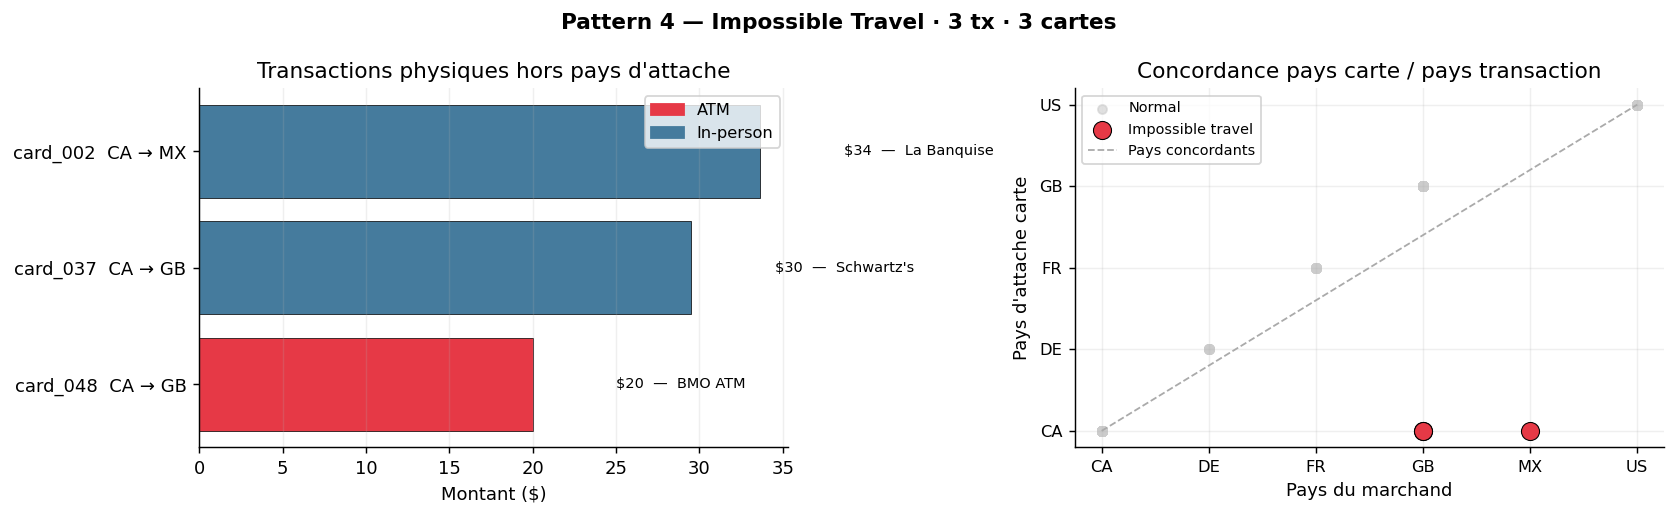

In [5]:
# Pays d'attache = pays physique dominant de la carte
home = (df[df["channel"].isin(["in_person", "atm"])]
        .groupby("card_id")["cardholder_country"]
        .agg(lambda x: x.mode().iloc[0]))

phys  = df[df["channel"].isin(["in_person", "atm"])].copy()
phys["home"] = phys["card_id"].map(home)
geo   = phys[phys["merchant_country"] != phys["home"]].copy()
geo["label"] = geo["card_id"] + "  " + geo["home"] + " → " + geo["merchant_country"]

print(f"Flags impossible travel : {len(geo)} transactions, {geo['card_id'].nunique()} cartes")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# --- barres : montants des transactions suspectes ---
geo_sorted = geo.sort_values("amount", ascending=True)
colors = ["#E63946" if ch == "atm" else "#457B9D" for ch in geo_sorted["channel"]]
bars = ax1.barh(geo_sorted["label"], geo_sorted["amount"], color=colors, edgecolor="black", lw=0.4)
for bar, (_, r) in zip(bars, geo_sorted.iterrows()):
    ax1.text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
             f"${r['amount']:.0f}  —  {r['merchant_name']}", va="center", fontsize=8)
patches = [mpatches.Patch(color="#E63946", label="ATM"), mpatches.Patch(color="#457B9D", label="In-person")]
ax1.legend(handles=patches, fontsize=9)
ax1.set(xlabel="Montant ($)", title="Transactions physiques hors pays d'attache")
ax1.grid(axis="x", alpha=0.2)

# --- scatter : pays d'attache vs pays transaction (toutes txns physiques) ---
phys_all = phys.copy()
phys_all["is_geo"] = phys_all["transaction_id"].isin(geo["transaction_id"])

countries = sorted(phys_all["home"].unique())
merch_countries = sorted(phys_all["merchant_country"].unique())
home_idx  = {c: i for i, c in enumerate(countries)}
merch_idx = {c: i for i, c in enumerate(merch_countries)}

normal = phys_all[~phys_all["is_geo"]]
flag   = phys_all[ phys_all["is_geo"]]

ax2.scatter([merch_idx[c] for c in normal["merchant_country"]],
            [home_idx[c]  for c in normal["home"]],
            color="#CCC", s=25, alpha=0.6, label="Normal")
ax2.scatter([merch_idx[c] for c in flag["merchant_country"]],
            [home_idx[c]  for c in flag["home"]],
            color="#E63946", s=100, edgecolors="black", lw=0.6, zorder=3, label="Impossible travel")
ax2.plot([0, len(merch_countries)-1], [0, len(countries)-1],
         color="#aaa", ls="--", lw=1, label="Pays concordants")
ax2.set_xticks(range(len(merch_countries))); ax2.set_xticklabels(merch_countries, fontsize=9)
ax2.set_yticks(range(len(countries)));       ax2.set_yticklabels(countries, fontsize=9)
ax2.set(xlabel="Pays du marchand", ylabel="Pays d'attache carte",
        title="Concordance pays carte / pays transaction")
ax2.legend(fontsize=8); ax2.grid(alpha=0.2)

fig.suptitle(f"Pattern 4 — Impossible Travel · {len(geo)} tx · {geo['card_id'].nunique()} cartes",
             fontweight="bold", fontsize=12)
plt.tight_layout()
plt.show()

---
## Synthèse — Scoring combiné

Les signaux des 4 patterns sont combinés par **noisy-OR** : des signaux indépendants se renforcent, un seul signal faible ne suffit pas à flaguer seul.

```
score_final = 1 − ∏(1 − scoreᵢ)
```
Une transaction est flaggée si `score ≥ 0.50`.

Flaggées : 74 / 1000 (7.4%)

transaction_id  card_id  amount      merchant_name  card_testing  cashout  merchant_ring  impossible_travel  fraud_score
     tx_000947 card_023    1.50 Shopify Merchant 1          0.95      0.0            0.0                0.0         0.95
     tx_000977 card_038    5.39 Shopify Merchant 2          0.95      0.0            0.0                0.0         0.95
     tx_000972 card_038   11.41 Shopify Merchant 1          0.95      0.0            0.0                0.0         0.95
     tx_000973 card_038    2.70 Shopify Merchant 2          0.95      0.0            0.0                0.0         0.95
     tx_000974 card_038   11.57 Shopify Merchant 1          0.95      0.0            0.0                0.0         0.95
     tx_000976 card_038    4.17 Shopify Merchant 1          0.95      0.0            0.0                0.0         0.95
     tx_000975 card_038   11.32         AliExpress          0.95      0.0            0.0                0.0         0.95
   

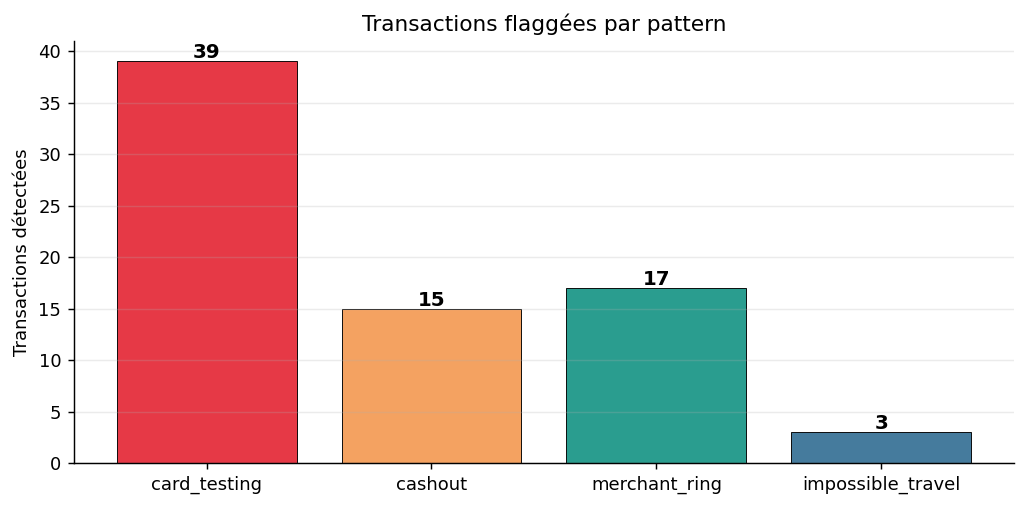

In [6]:
# Scores individuels par pattern
scores = {
    "card_testing":  {tid: 0.95 for wins in bursts.values() for tid in wins["transaction_id"]},
    "cashout":       dict(zip(cashouts["transaction_id"], [0.90] * len(cashouts))),
    "merchant_ring": dict(zip(ring_df["transaction_id"],  [0.85] * len(ring_df))),
    "impossible_travel": dict(zip(geo["transaction_id"], [0.90] * len(geo))),
}

def noisy_or(score_list):
    return 1 - np.prod([1 - s for s in score_list])

results = []
for _, row in df.iterrows():
    tid  = row["transaction_id"]
    sigs = {pat: s[tid] for pat, s in scores.items() if tid in s}
    results.append({"transaction_id": tid, "card_id": row["card_id"],
                    "amount": row["amount"], "merchant_name": row["merchant_name"],
                    **{p: sigs.get(p, 0) for p in scores},
                    "fraud_score": noisy_or(sigs.values()) if sigs else 0.0})

scored = pd.DataFrame(results)
flagged = scored[scored["fraud_score"] >= 0.50].sort_values("fraud_score", ascending=False)

print(f"Flaggées : {len(flagged)} / {len(df)} ({len(flagged)/len(df):.1%})\n")
print(flagged[["transaction_id","card_id","amount","merchant_name",
               "card_testing","cashout","merchant_ring","impossible_travel",
               "fraud_score"]].head(20).to_string(index=False))

# Répartition par pattern
fig, ax = plt.subplots(figsize=(8, 4))
pat_counts = {p: (scored[p] > 0).sum() for p in scores}
bars = ax.bar(pat_counts.keys(), pat_counts.values(),
              color=["#E63946","#F4A261","#2A9D8F","#457B9D"],
              edgecolor="black", lw=0.5)
for bar, v in zip(bars, pat_counts.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(v), ha="center", fontweight="bold", fontsize=11)
ax.set(ylabel="Transactions détectées", title="Transactions flaggées par pattern")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()